# V2 Runned JEPA World Model Planner Analysis

Executed Kaggle notebook retained as the V2 world-model/planner result record.


## V2 Run Interpretation

This V2 run is valid and materially better than V1 from an engineering standpoint: the notebook no longer diverges to `NaN`, all reported backtests are finite, and the statistical tests are marked valid.

Dataset and setup:

- rows: `165325`
- assets: `31`
- features: `29`
- V2 train samples: `74120`
- validation samples: `15120`
- test samples: `16040`
- loaded checkpoint: `models/v2_world_model_run2.pt`

Main test-period results:

| Model | Total Return | CAGR | Sharpe | Sortino | Max Drawdown | Avg Turnover | Total Cost |
|---|---:|---:|---:|---:|---:|---:|---:|
| Buy & Hold | `0.171` | `0.047` | `1.832` | `2.484` | `-0.034` | `0.0005` | `0.20` |
| Equal Weight | `1.144` | `0.250` | `1.828` | `2.470` | `-0.161` | `0.0023` | `1.00` |
| Vol Target | `0.868` | `0.201` | `1.669` | `2.314` | `-0.146` | `0.0403` | `23.93` |
| V2 JEPA Planner | `0.843` | `0.196` | `1.520` | `2.162` | `-0.146` | `0.4000` | `242.87` |
| Momentum | `0.858` | `0.199` | `1.401` | `2.216` | `-0.132` | `0.2475` | `158.93` |

Interpretation:

- V2 is no longer numerically broken: `valid_backtest=True` for all strategies.
- The V2 planner beats Buy & Hold in total return and daily excess-return bootstrap (`p=0.003` vs Buy & Hold), but it does not beat the strongest simple baselines.
- Equal Weight is the best strategy in total return and Sharpe in this run.
- The randomization test gives `p_value_random_beats_agent = 0.26`, meaning 26% of random constrained strategies beat the V2 planner. This is not strong evidence that the planner is better than random under the current action constraints.
- The V2 planner trades too much: average turnover is exactly `0.40`, which is the configured max turnover. This means the planner is saturating the turnover constraint almost every day, creating very high total transaction costs (`242.87`).
- The planner chooses horizon `5` in the displayed tail, suggesting it may be collapsing to short-horizon decisions instead of using the full multi-horizon action space.

Conclusion: V2 fixes the V1 numerical/architecture failure and produces a valid backtest, but the trading policy is not yet good. The next improvements should focus on turnover-aware energy scoring, action smoothness, horizon diversification, and stronger comparison against equal-weight / vol-target baselines.


In [1]:
import os
import sys
from pathlib import Path

REPO = Path('/kaggle/working/jepa-for-trading')
if not REPO.exists():
    !git clone -b version2 https://github.com/aurvl/jepa-for-trading.git {REPO}
%cd /kaggle/working/jepa-for-trading
!{sys.executable} -m pip install -q -e . --no-deps

SRC = str(REPO / 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import jepa_trading
print('jepa_trading loaded from:', jepa_trading.__file__)

Cloning into '/kaggle/working/jepa-for-trading'...
remote: Enumerating objects: 137, done.
remote: Counting objects: 100% (137/137), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 137 (delta 38), reused 125 (delta 26), pack-reused 0 (from 0)
Receiving objects: 100% (137/137), 515.92 KiB | 3.91 MiB/s, done.
Resolving deltas: 100% (38/38), done.
/kaggle/working/jepa-for-trading
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for jepa-trading (pyproject.toml) ... done
jepa_trading loaded from: /kaggle/working/jepa-for-trading/src/jepa_trading/__init__.py


In [4]:
import os
import sys
from pathlib import Path
REPO = Path("/kaggle/working/jepa-for-trading")

if not REPO.exists():
    !git clone -b version2 https://github.com/aurvl/jepa-for-trading.git {REPO}
else:
    %cd /kaggle/working/jepa-for-trading
    !git fetch origin version2
    !git checkout version2
    !git pull origin version2

%cd /kaggle/working/jepa-for-trading
!{sys.executable} -m pip install -q -e . --no-deps

/kaggle/working/jepa-for-trading
From https://github.com/aurvl/jepa-for-trading
 * branch            version2   -> FETCH_HEAD
Already on 'version2'
Your branch is up to date with 'origin/version2'.
From https://github.com/aurvl/jepa-for-trading
 * branch            version2   -> FETCH_HEAD
Already up to date.
/kaggle/working/jepa-for-trading
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for jepa-trading (pyproject.toml) ... done


In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch

from jepa_trading.config import ensure_dirs, load_config
from jepa_trading.data.pipeline import prepare_market_data, create_v2_dataloaders
from jepa_trading.data.v2_dataset import PortfolioActionConfig
from jepa_trading.models.world_model_v2 import V2WorldModel
from jepa_trading.training.train_v2 import train_v2_world_model
from jepa_trading.training.checkpoints import load_checkpoint
from jepa_trading.planning.v2_planner import V2ImaginationPlanner
from jepa_trading.evaluation.v2_backtest import run_v2_planner_backtest
from jepa_trading.evaluation.backtest import run_weight_strategy, buy_and_hold_weight, equal_weight, momentum_weight, volatility_target_weight, random_long_only_weight
from jepa_trading.evaluation.metrics import metrics_table, validate_backtest_histories
from jepa_trading.evaluation.plots import plot_equity_curves, plot_drawdown, plot_turnover
from jepa_trading.evaluation.statistical_tests import randomization_p_value, bootstrap_mean_return_p_value
from jepa_trading.rl.env import TradingEnv
from jepa_trading.rl.observer import RawMarketObserver
from jepa_trading.utils.device import get_device
from jepa_trading.utils.seed import seed_everything


In [6]:
config = load_config('configs/default.yaml')

macro_candidates = []
if Path('/kaggle/input').exists():
    macro_candidates.extend(Path('/kaggle/input').rglob('macro_data.parquet'))
    macro_candidates.extend(Path('/kaggle/input').rglob('estimated_volatility_with_macro.csv'))
    macro_candidates.extend(Path('/kaggle/input').rglob('*macro*.csv'))
explicit_macro_csv = Path('/kaggle/input/datasets/aurelvehi/estimated-volatility-with-macro/estimated_volatility_with_macro.csv')
if explicit_macro_csv.exists():
    macro_candidates.insert(0, explicit_macro_csv)
if macro_candidates:
    config['data']['macro_path'] = str(macro_candidates[0])
print('Macro file used:', config['data']['macro_path'])

# Trading modes: long_only, long_short, market_neutral.
config['portfolio']['mode'] = 'long_only'

FAST_DEV_RUN = False
if FAST_DEV_RUN:
    config['data']['tickers'] = config['data']['tickers'][:8]
    config['training']['batch_size'] = 8
    config['v2']['world_max_steps'] = 30
    config['v2']['world_warmup_steps'] = 10
    config['training']['eval_every'] = 10
    config['v2']['planner_action_samples'] = 16

ensure_dirs(config)
seed_everything(config['seed'])
device = get_device(config['device'])
device

Macro file used: /kaggle/input/datasets/aurelvehi/estimated-volatility-with-macro/estimated_volatility_with_macro.csv


device(type='cuda')

In [8]:
prepared_df, arrays, feature_columns = prepare_market_data(config, force_download=False)
loaders = create_v2_dataloaders(config, arrays)

sample_batch = next(iter(loaders['train']))
portfolio_state_dim = sample_batch['portfolio_state'].shape[-1]
action_dim = sample_batch['action'].shape[-1]

print('rows:', len(prepared_df))
print('dates:', arrays.dates.min(), '->', arrays.dates.max())
print('assets:', len(arrays.tickers), arrays.tickers)
print('features:', len(feature_columns), feature_columns)
print('portfolio_state_dim:', portfolio_state_dim, 'action_dim:', action_dim)
print('dataset sizes:', {k: len(v.dataset) for k, v in loaders.items()})

rows: 165325
dates: 2005-01-03 00:00:00 -> 2026-06-10 00:00:00
assets: 31 ['AAPL', 'AMZN', 'BA', 'BAC', 'CAT', 'COST', 'CVX', 'GE', 'GLD', 'GOOGL', 'HD', 'IWM', 'JNJ', 'JPM', 'KO', 'META', 'MSFT', 'NVDA', 'PFE', 'PG', 'QQQ', 'SPY', 'TLT', 'UNH', 'WMT', 'XLE', 'XLF', 'XLI', 'XLK', 'XLV', 'XOM']
features: 29 ['log_return', 'overnight_gap', 'intraday_range', 'volume_z', 'rsi_scaled', 'macd', 'rolling_vol_21', 'rolling_vol_63', 'sigma_log', 't1_growth_pulse__raw_factor', 't2_macro_repricing__raw_factor', 't3_inflation_pressure__raw_factor', 't4_financial_stress__raw_factor', 't5_technical_pressure__raw_factor', 't1_growth_pulse__score', 't2_macro_repricing__score', 't3_inflation_pressure__score', 't4_financial_stress__score', 't5_technical_pressure__score', 'theme_growth_raw_factor', 'theme_fx_rates_raw_factor', 'theme_inflation_commodity_raw_factor', 'theme_stress_raw_factor', 'theme_technical_pressure_raw_factor', 'theme_growth_score', 'theme_fx_rates_score', 'theme_inflation_commodity_s

In [9]:
model = V2WorldModel(
    n_features=len(feature_columns),
    max_assets=len(arrays.tickers),
    portfolio_state_dim=portfolio_state_dim,
    action_dim=action_dim,
    **config['model'],
    ema_decay=config['training']['ema_decay'],
    hidden_dim=config['v2']['hidden_dim'],
    policy_mode=config['portfolio']['mode'],
    max_abs_weight=config['portfolio']['max_long_weight'],
)

v2_ckpt = Path(config['training']['checkpoint_dir']) / 'v2_world_model_run2.pt'
if v2_ckpt.exists():
    print('Loading V2 world model checkpoint:', v2_ckpt)
    load_checkpoint(v2_ckpt, model, map_location=device)
    v2_history = pd.DataFrame()
else:
    v2_history = train_v2_world_model(
        model=model,
        train_loader=loaders['train'],
        val_loader=loaders['val'],
        device=device,
        max_steps=config['v2']['world_max_steps'],
        warmup_steps=config['v2']['world_warmup_steps'],
        lr=config['training']['lr'],
        weight_decay=config['training']['weight_decay'],
        checkpoint_path=v2_ckpt,
        weights=config['v2']['loss_weights'],
        eval_every=config['training']['eval_every'],
        log_every=config['training']['log_every'],
    )
    load_checkpoint(v2_ckpt, model, map_location=device)
v2_history.tail()

Loading V2 world model checkpoint: models/v2_world_model_run2.pt


/kaggle/working/jepa-for-trading/src/jepa_trading/models/encoders.py:51: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)


""


In [10]:
portfolio_cfg = config['portfolio']
action_cfg = PortfolioActionConfig(
    mode=portfolio_cfg['mode'],
    cash_initial=portfolio_cfg['cash_initial'],
    transaction_cost_bps=portfolio_cfg['transaction_cost_bps'],
    max_long_weight=portfolio_cfg['max_long_weight'],
    max_short_weight=portfolio_cfg['max_short_weight'],
    max_gross_exposure=portfolio_cfg['max_gross_exposure'],
    max_net_exposure=portfolio_cfg['max_net_exposure'],
    borrow_cost_bps=portfolio_cfg['borrow_cost_bps'],
    n_action_samples=config['v2']['planner_action_samples'],
)
planner = V2ImaginationPlanner(
    model=model,
    action_config=action_cfg,
    horizons=config['data']['horizons'],
    n_action_samples=config['v2']['planner_action_samples'],
    device=device,
    seed=config['seed'],
)

test_start = pd.Timestamp(config['data']['val_end']) + pd.Timedelta(days=1)
test_end = arrays.dates.max()
agent_hist = run_v2_planner_backtest(
    arrays=arrays,
    planner=planner,
    start_date=test_start,
    end_date=test_end,
    lookback=config['data']['lookback'],
    cash_initial=config['portfolio']['cash_initial'],
    transaction_cost_bps=config['portfolio']['transaction_cost_bps'],
    max_weight_per_asset=config['portfolio']['max_weight_per_asset'],
    max_turnover=config['portfolio']['max_turnover'],
    mode=config['portfolio']['mode'],
    max_long_weight=config['portfolio']['max_long_weight'],
    max_short_weight=config['portfolio']['max_short_weight'],
    max_gross_exposure=config['portfolio']['max_gross_exposure'],
    max_net_exposure=config['portfolio']['max_net_exposure'],
    borrow_cost_bps=config['portfolio']['borrow_cost_bps'],
)
agent_hist.tail()


,date,equity,reward,log_return,turnover,cost,drawdown,cash_weight,planned_horizon,planner_score,predicted_log_return,predicted_drawdown,predicted_vol
855,2026-06-03,1836.475098,-0.023652,0.000247,0.4,0.367204,-0.014097,0.011136,5,-0.071944,-0.013999,-0.029547,0.206963
856,2026-06-04,1851.939697,-0.013755,0.008386,0.4,0.367295,-0.005795,0.004929,5,-0.074561,-0.013005,-0.028192,0.202766
857,2026-06-05,1838.339600,-0.030958,-0.007371,0.4,0.370388,-0.013096,0.001370,5,-0.074513,-0.014224,-0.029753,0.205226
858,2026-06-08,1839.078369,-0.023082,0.000402,0.4,0.367668,-0.012700,0.000741,5,-0.074662,-0.015629,-0.030817,0.205621
859,2026-06-09,1844.408447,-0.019924,0.002894,0.4,0.367816,-0.009838,0.000437,5,-0.075573,-0.014672,-0.028445,0.203891


In [11]:
observer = RawMarketObserver(arrays, config['data']['lookback'])
def make_test_env():
    return TradingEnv(
        arrays,
        observer,
        start_date=test_start,
        end_date=test_end,
        lookback=config['data']['lookback'],
        cash_initial=config['portfolio']['cash_initial'],
        transaction_cost_bps=config['portfolio']['transaction_cost_bps'],
        max_weight_per_asset=config['portfolio']['max_weight_per_asset'],
        max_turnover=config['portfolio']['max_turnover'],
    )

bh_hist = run_weight_strategy(make_test_env(), buy_and_hold_weight)
equal_hist = run_weight_strategy(make_test_env(), equal_weight)
mom_hist = run_weight_strategy(make_test_env(), momentum_weight)
vol_hist = run_weight_strategy(make_test_env(), volatility_target_weight)
rng = np.random.default_rng(config['seed'])
random_hists = [
    run_weight_strategy(make_test_env(), lambda env, mask, rng=rng: random_long_only_weight(env, mask, rng))
    for _ in range(100)
]

histories = {
    'V2 JEPA Planner': agent_hist,
    'Buy & Hold': bh_hist,
    'Equal Weight': equal_hist,
    'Momentum': mom_hist,
    'Vol Target': vol_hist,
}
validity_report = validate_backtest_histories(histories)
print(validity_report.to_string(index=False))
if not validity_report['valid_backtest'].all():
    print('INVALID BACKTEST: at least one strategy has NaN/inf/non-positive equity. Do not interpret metrics positively.')
metrics_table(histories)


          model  valid_backtest invalid_reason
V2 JEPA Planner            True               
     Buy & Hold            True               
   Equal Weight            True               
       Momentum            True               
     Vol Target            True               


,model,valid_backtest,invalid_reason,total_return,cagr,annualized_vol,sharpe,sortino,max_drawdown,hit_rate,avg_turnover,total_cost,avg_cash_weight
1,Buy & Hold,True,,0.170976,0.047336,0.025426,1.831867,2.484173,-0.033833,0.563953,0.000465,0.200000,0.800000
2,Equal Weight,True,,1.144134,0.250445,0.126699,1.827907,2.470382,-0.160927,0.563953,0.002326,1.003544,0.002326
4,Vol Target,True,,0.867995,0.200935,0.113615,1.668775,2.314209,-0.146207,0.554651,0.040298,23.933073,0.002326
0,V2 JEPA Planner,True,,0.842650,0.196137,0.122797,1.520110,2.161860,-0.145796,0.559302,0.400000,242.871863,0.013331
3,Momentum,True,,0.857835,0.199017,0.136146,1.401319,2.215595,-0.132375,0.533721,0.247484,158.926727,0.255415


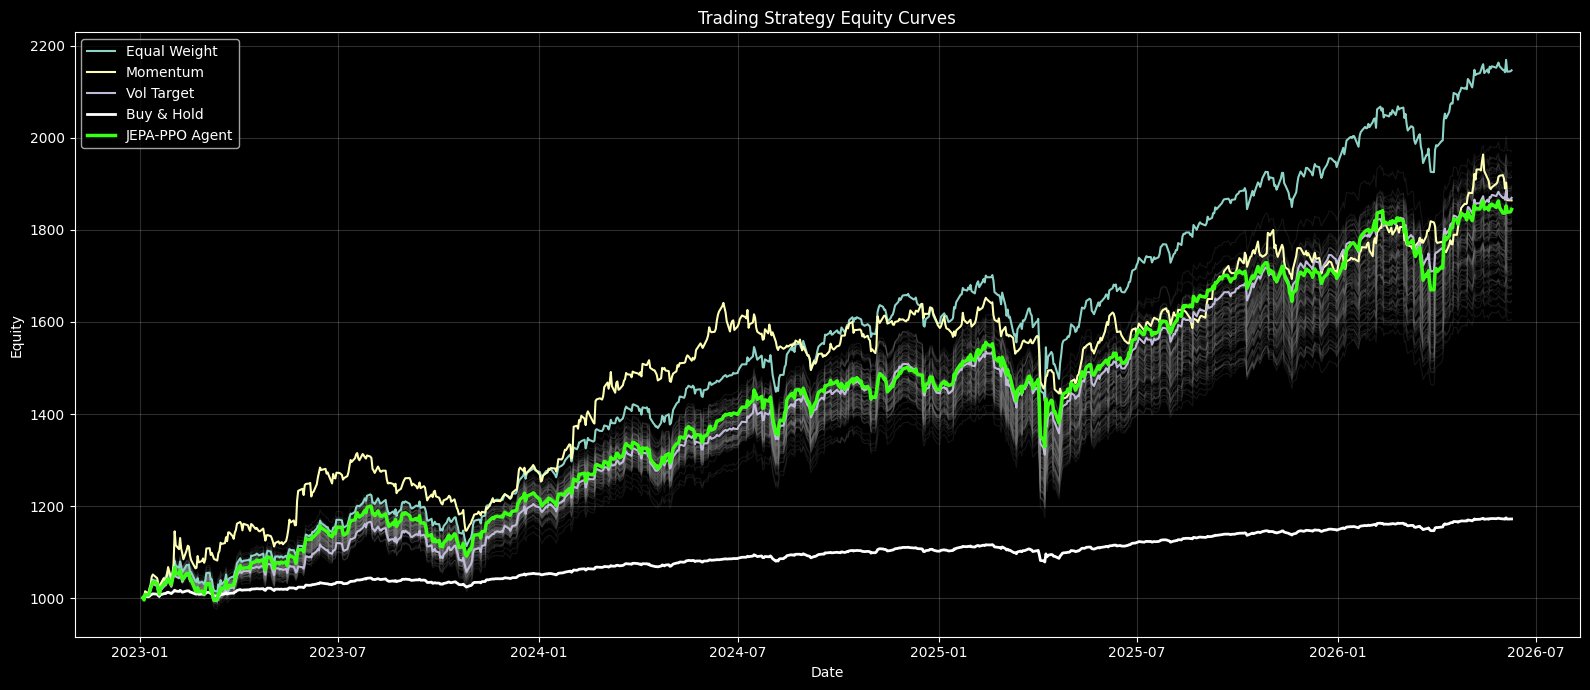

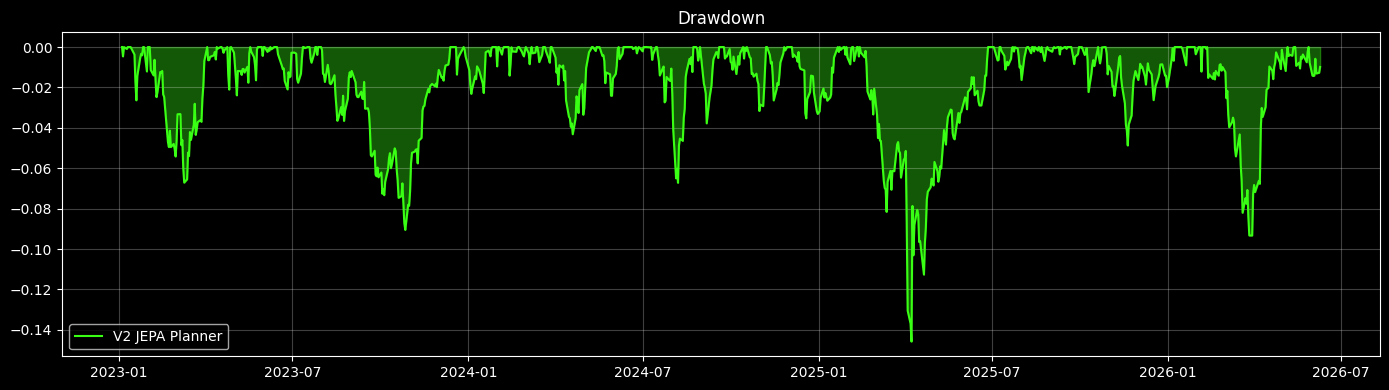

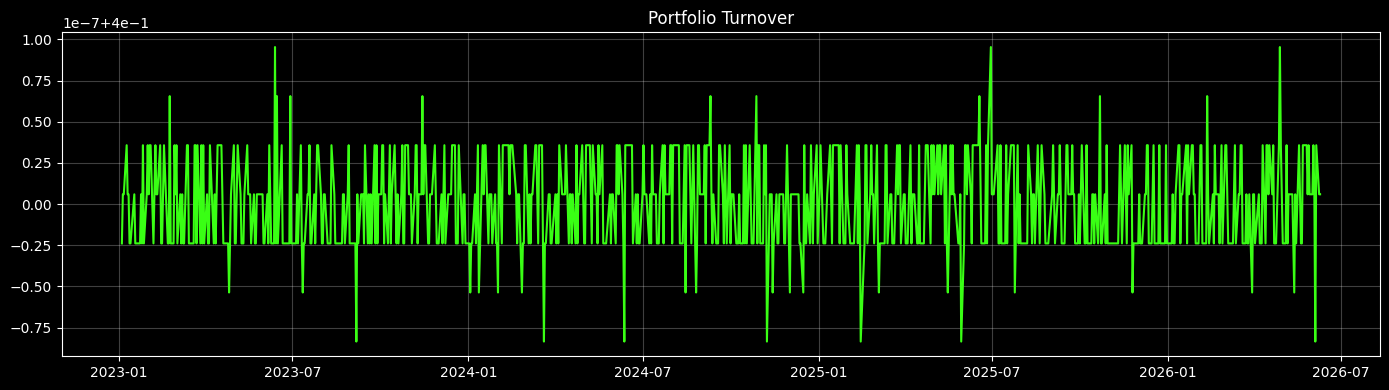

Randomization test: {'valid_test': True, 'invalid_reason': '', 'agent_total_return': 0.8426498098707917, 'random_mean_total_return': 0.7907976012739063, 'random_best_total_return': 0.9656430899432527, 'p_value_random_beats_agent': 0.26}
Bootstrap vs Buy & Hold: {'valid_test': True, 'invalid_reason': '', 'mean_daily_excess_return': 0.0005565533898727056, 'bootstrap_p_value_leq_zero': 0.003}


,date,equity,planned_horizon,planner_score,predicted_log_return,predicted_drawdown
855,2026-06-03,1836.475098,5,-0.071944,-0.013999,-0.029547
856,2026-06-04,1851.939697,5,-0.074561,-0.013005,-0.028192
857,2026-06-05,1838.339600,5,-0.074513,-0.014224,-0.029753
858,2026-06-08,1839.078369,5,-0.074662,-0.015629,-0.030817
859,2026-06-09,1844.408447,5,-0.075573,-0.014672,-0.028445


In [12]:
plot_equity_curves(agent_hist, bh_hist, random_hists, extra={'Equal Weight': equal_hist, 'Momentum': mom_hist, 'Vol Target': vol_hist})
plot_drawdown(agent_hist, label='V2 JEPA Planner')
plot_turnover(agent_hist)
rand_test = randomization_p_value(agent_hist, random_hists)
boot_test = bootstrap_mean_return_p_value(agent_hist, bh_hist)
print('Randomization test:', rand_test)
print('Bootstrap vs Buy & Hold:', boot_test)
if not rand_test.get('valid_test', False) or not boot_test.get('valid_test', False):
    print('INVALID STATISTICAL TEST: non-finite inputs detected; no positive conclusion is allowed.')
agent_hist[['date', 'equity', 'planned_horizon', 'planner_score', 'predicted_log_return', 'predicted_drawdown']].tail()


## Push Summary

Git push cell output was redacted before committing this notebook. The run artifacts were pushed to `version2` with LFS, including `models/v2_world_model.pt`, `models/v2_world_model_run2.pt`, and `data/cache/prices.parquet`.
